# **Exercicio Duelo de Modelos 4**

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:**
Selecione um dos modelos que foram explorados nos duelos de modelos ao longo do curso. Pode ser SVM, Random Forest, XGBoost, ou qualquer outro que tenhamos abordado.

**2. Aperfeiçoamento:**
**Aplique as técnicas que aprendemos para melhorar o desempenho do seu modelo:**

**Hiperparâmetros:** Utilize GridSearchCV ou RandomSearchCV para encontrar os melhores parâmetros.

**Cross Validation:** Avalie a robustez do modelo utilizando validação cruzada para garantir que ele generaliza bem.

**Balanceamento de Classes:** Se o seu modelo lida com problemas de classes desbalanceadas, explore técnicas como SMOTE, undersampling ou oversampling.

**Padronização e Normalização:** Lembre-se de padronizar os dados, especialmente se for usar modelos que são sensíveis à escala das variáveis.

**3. Submissão no Kaggle:**
Treine o seu modelo com os dados de treino e gere as previsões para os dados de teste. Lembre-se de que o conjunto de teste não possui a variável alvo (y_test), pois a avaliação será feita com base nas submissões no Kaggle.
Submeta suas previsões na competição do Titanic no Kaggle.

**4. Entrega:**
Envie o código que você desenvolveu, detalhando cada etapa do seu processo de modelagem, explicando as escolhas feitas e como essas ajudaram a melhorar o modelo.

Junto com o código, envie um print do seu score obtido na plataforma do Kaggle. Esse score será a sua métrica final de avaliação, mostrando como o seu modelo se compara com os demais.

**5. Competição Saudável:**
A ideia é trazer um senso de competição saudável, então não vale replicar exatamente o que fizemos na aula! Inove, explore novas combinações de parâmetros e técnicas, e mostre do que é capaz. O importante é exercitar o pensamento crítico e a capacidade de experimentar.

**Dicas Finais:**

Seja criativo e tenha um olhar crítico sobre o que pode ser melhorado.
Teste diferentes abordagens e não se prenda a um único caminho.
Lembre-se de que, mais do que alcançar o melhor score, o objetivo é aprender e aplicar o conhecimento de forma prática e eficaz.
Boa sorte! Estamos ansiosos para ver como cada um de vocês vai se sair nesse desafio e quais insights irão surgir dessa competição!

Ao final dessa atividade vocês terão participado da primeira competição publica de ciência de dados de vocês = )




# Modelo XGBoost para classificação de sobreviventes no Titanic

### Importa bibliotecas e dados

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Tratamento e limpeza dos dados

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


No dataframe de treino, as colunas `Age`, `Cabin` e `Embarked` possuem valores nulos.

No dataframe de teste, as colunas `Age`, `Fare` e `Cabin` possuem valores nulos.

In [7]:
# Preenchendo os valores nulos da coluna Age com a mediana das idades
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

C:\Users\lucas\AppData\Local\Temp\ipykernel_24132\1143670120.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\lucas\AppData\Local\Temp\ipykernel_24132\1143670120.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [8]:
# Para a variável 'Cabin', podemos apenas transformar a coluna indicando se a cabine é conhecida ou não
train_df['Cabin'] = train_df['Cabin'].notna().astype(int)
test_df['Cabin'] = test_df['Cabin'].notna().astype(int)

In [9]:
# Como são apenas 2 linhas faltantes no train_df para a variável Embarked, irei apenas removê-las do dataframe
train_df.dropna(subset=['Embarked'], inplace=True)

In [10]:
# Preenchendo os valores nulos da coluna Fare com a mediana das idades
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

C:\Users\lucas\AppData\Local\Temp\ipykernel_24132\3277459080.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)


As colunas `Name`, `Sex`, `Ticket` e `Embarked` são do tipo _string_. Vamos tratá-las!

In [11]:
# As colunas Name e Ticket não são relevantes para descobrir se a pessoa sobreviveu ou não,
# portanto vamos removê-las
train_df = train_df.drop(columns=['Name','Ticket'])
test_df = test_df.drop(columns=['Name','Ticket'])

In [12]:
# Para a coluna Sex, converter Male em 0 e Female em 1
print(train_df['Sex'].unique())
print(test_df['Sex'].unique())

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

['male' 'female']
['male' 'female']


In [13]:
# Para a variável 'Embarked', podemos usar One-Hot Encoding, pois há mais de duas categorias
print(train_df['Embarked'].unique())
print(test_df['Embarked'].unique())

train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked')

['S' 'C' 'Q']
['Q' 'S' 'C']


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    int64  
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Cabin        889 non-null    int64  
 9   Embarked_C   889 non-null    bool   
 10  Embarked_Q   889 non-null    bool   
 11  Embarked_S   889 non-null    bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 72.1 KB


In [15]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         418 non-null    float64
 7   Cabin        418 non-null    int64  
 8   Embarked_C   418 non-null    bool   
 9   Embarked_Q   418 non-null    bool   
 10  Embarked_S   418 non-null    bool   
dtypes: bool(3), float64(2), int64(6)
memory usage: 27.5 KB


Com as colunas tratadas, vamos dropar a coluna PassengerId pois ela é apenas um índice

Hora de separa em X e y nossos dados

In [16]:
# Separa em X_treino, Y_treino e X_teste
X_train = train_df.drop(columns=['Survived', 'PassengerId'])
y_train = train_df['Survived']
X_test = test_df.drop(columns=['PassengerId'])

### Balanceamente e Padronização dos dados

In [17]:
# Balanceando os dados com SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, y_train)
print("\nDistribuição das classes depois do balanceamento:")
print(Y_train_balanced.value_counts())


Distribuição das classes depois do balanceamento:
Survived
0    549
1    549
Name: count, dtype: int64


In [18]:
# Padronizando os dados
scaler = StandardScaler()
# Ajustando e transformando os dados de treino balanceados
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

### Instancia e escolhe os hiperparametros do XGBoost

In [19]:
# Instancia o modelo
xgboost_model = xgb.XGBClassifier(random_state=37)

In [20]:
param_grid_xgboost = {
    'max_depth': [4, 5, 6, 7, 8],                # Profundidade máxima da árvore
    'n_estimators': [100, 200, 300],     # Número de árvores
    'learning_rate': [0.25, 0.05, 0.1, 0.2, 0,5],   # Taxa de aprendizado
    'booster': ['gbtree', 'gblinear', 'dart']  # Especifica qual booste usar
}

In [21]:
grid_search_xgboost = GridSearchCV(
    estimator=xgboost_model,   # Modelo a ser usado
    param_grid=param_grid_xgboost,      # Conjunto de parâmetros
    scoring='accuracy',         # Métrica de avaliação
    cv=4,                       # Número de folds para cross-validation
    n_jobs=-1                   # Usa todos os processadores disponíveis
)

In [22]:
grid_search_xgboost.fit(X_train_balanced_scaled, Y_train_balanced)

# Melhor modelo e parâmetros
print("Melhores Parâmetros:", grid_search_xgboost.best_params_)
print("Melhor Acurácia:", grid_search_xgboost.best_score_)

Melhores Parâmetros: {'booster': 'gbtree', 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}
Melhor Acurácia: 0.8215295288652953


In [23]:
best_model_xgboost = grid_search_xgboost.best_estimator_
y_pred_xgboost = best_model_xgboost.predict(X_train_balanced_scaled)

In [24]:
accuracy = accuracy_score(Y_train_balanced, y_pred_xgboost)
relatorio = classification_report(Y_train_balanced, y_pred_xgboost)

print(f'Acurácia: {accuracy}')
print("Relatório de Classificação:")
print(relatorio)

Acurácia: 0.918943533697632
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       549
           1       0.95      0.89      0.92       549

    accuracy                           0.92      1098
   macro avg       0.92      0.92      0.92      1098
weighted avg       0.92      0.92      0.92      1098



Os resultados foram muito bons. A acurácia de 91,9% é bastante elevada e as métricas de precisão (*precision*), revocação (*recall*) e F1-score, todas próximas de 0,90, também indicam um excelente desempenho do modelo.

Entretanto, resultados tão elevados podem ser um indício de *overfitting*, ou seja, o modelo pode ter aprendido excessivamente os padrões do conjunto de treinamento e não generalizar tão bem para novos dados.

Para verificar essa hipótese, vamos submeter as previsões geradas para o conjunto de teste e analisar seu desempenho. Isso permitirá avaliar se o modelo está sofrendo de *overfitting* ou se realmente apresenta uma boa capacidade de generalização.


### Salvando o resultado e preparando-o para submeter no Kaggle

In [25]:
# Faz a previsão a partir do X_test
Y_test_pred = best_model_xgboost.predict(X_test_scaled)
Y_test_pred

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [26]:
# Insere a coluna PassengerId necessária para submissão no Kaggle
sub_xgboost = pd.Series(Y_test_pred, index=test_df['PassengerId'], name = 'Survived')
sub_xgboost

PassengerId
892     0
893     0
894     1
895     1
896     0
       ..
1305    1
1306    1
1307    0
1308    1
1309    0
Name: Survived, Length: 418, dtype: int64

In [27]:
# Salva as previsões em .csv
sub_xgboost.to_csv("xgboost.csv" , header=True)

### Resultado

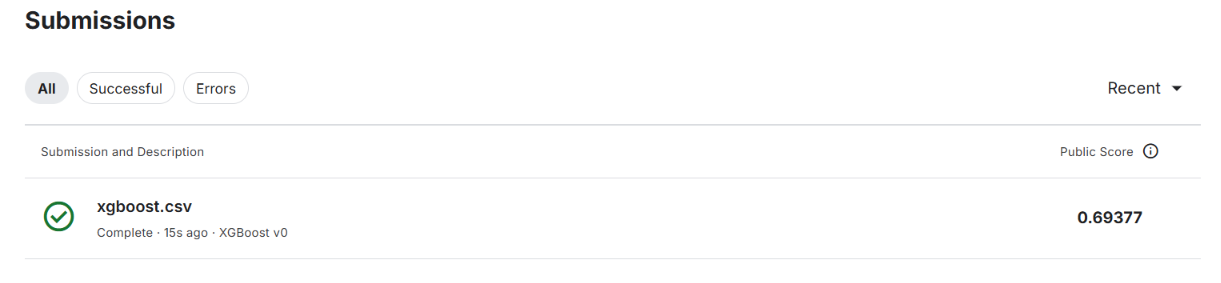

In [28]:
Image('Modelo v0.png')

Os resultados indicam que o modelo está, de fato, sofrendo de *overfitting*. Embora tenha apresentado um desempenho excelente durante o treinamento, a acurácia de 69,377% obtida no conjunto de teste mostra uma queda significativa na capacidade de generalização.

Isso sugere que o modelo aprendeu padrões muito específicos dos dados de treinamento e não conseguiu manter o mesmo desempenho em dados inéditos.

Diante disso, vamos retreinar o modelo utilizando técnicas que ajudem a reduzir o *overfitting* e melhorar sua capacidade de generalização.

### Modelo com regularização

Para evitar o *overfitting*, vamos:
* adicionar a regularização
* diminuar a complexidade da árvore
* adicionar amostragem

In [29]:
# Instancia o modelo
xgboost_sof = xgb.XGBClassifier(random_state=37) # sof == Sem OverFitting

In [30]:
param_grid_xgboost_sof = {
    'max_depth': [2, 3, 4],                # Profundidade máxima da árvore
    'n_estimators': [300, 400, 500],       # Número de árvores
    'learning_rate': [0.025, 0.05, 0.1],   # Taxa de aprendizado
    'subsample': [0.8, 0.9],               # Proporção de amostras usadas para treinar cada árvore
    'colsample_bytree': [0.8, 0.9],        # Proporção de características para cada árvore
    'reg_alpha': [1,2],                    # regularização L1
    'reg_lambda': [1,2],                   # regularização L2
}

In [31]:
grid_search_xgboost_sof = GridSearchCV(
    estimator=xgboost_sof,      # Modelo a ser usado
    param_grid=param_grid_xgboost_sof,      # Conjunto de parâmetros
    scoring='accuracy',         # Métrica de avaliação
    cv=4,                       # Número de folds para cross-validation
    n_jobs=-1                   # Usa todos os processadores disponíveis
)

In [32]:
grid_search_xgboost_sof.fit(X_train_balanced_scaled, Y_train_balanced)

# Melhor modelo e parâmetros
print("Melhores Parâmetros:", grid_search_xgboost_sof.best_params_)
print("Melhor Acurácia:", grid_search_xgboost_sof.best_score_)

Melhores Parâmetros: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.9}
Melhor Acurácia: 0.8242634372926344


In [33]:
best_model_xgboost_sof = grid_search_xgboost_sof.best_estimator_
y_pred_xgboost_sof = best_model_xgboost_sof.predict(X_train_balanced_scaled)

In [34]:
accuracy_sof = accuracy_score(Y_train_balanced, y_pred_xgboost_sof)
relatorio_sof = classification_report(Y_train_balanced, y_pred_xgboost_sof)

print(f'Acurácia: {accuracy_sof}')
print("Relatório de Classificação:")
print(relatorio_sof)

Acurácia: 0.912568306010929
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       549
           1       0.93      0.89      0.91       549

    accuracy                           0.91      1098
   macro avg       0.91      0.91      0.91      1098
weighted avg       0.91      0.91      0.91      1098



Novamente, foram obtidos resultados bastante elevados, o que pode indicar a ocorrência de *overfitting*.

Para verificar se esse é realmente o caso, vamos gerar as previsões para o conjunto de teste e submetê-las ao Kaggle. Dessa forma, poderemos avaliar se o modelo apenas se ajustou excessivamente aos dados de treinamento ou se conseguiu generalizar bem para dados não vistos anteriormente.

In [35]:
# Faz a previsão a partir do X_test
Y_test_pred_sof = best_model_xgboost_sof.predict(X_test_scaled)
Y_test_pred_sof

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,

In [36]:
# Insere a coluna PassengerId necessária para submissão no Kaggle
sub_xgboost_sof = pd.Series(Y_test_pred_sof, index=test_df['PassengerId'], name = 'Survived')
sub_xgboost_sof

PassengerId
892     0
893     0
894     0
895     1
896     0
       ..
1305    1
1306    1
1307    0
1308    1
1309    1
Name: Survived, Length: 418, dtype: int64

In [37]:
# Salva as previsões em .csv
sub_xgboost_sof.to_csv("xgboostv1.csv" , header=True)

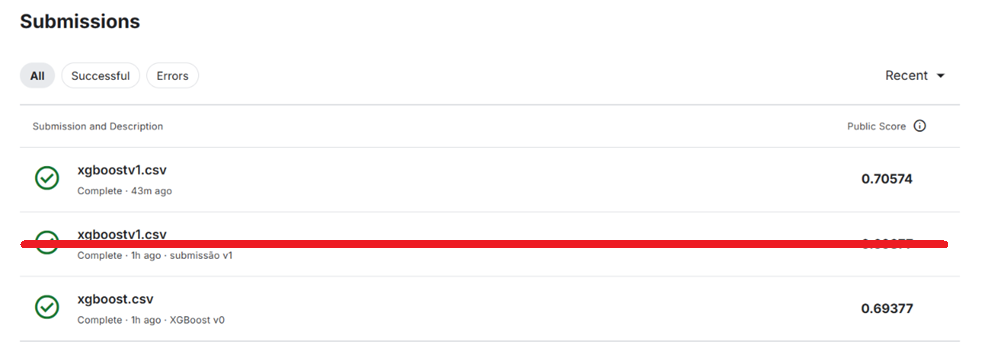

In [38]:
Image('Modelo v1.png')

Não tivemos uma melhora significativa...

### Vamos penalizar de verdade agora

In [39]:
# Instancia o modelo
xgboost_pen = xgb.XGBClassifier(random_state=37) # pen = Penalização

In [40]:
param_grid_xgboost_pen = {
    'max_depth': [2, 3, 4],                # Profundidade máxima da árvore
    'n_estimators': [300, 400, 500],       # Número de árvores
    'learning_rate': [0.025, 0.05, 0.1],   # Taxa de aprendizado
    'subsample': [0.8, 0.9],               # Proporção de amostras usadas para treinar cada árvore
    'colsample_bytree': [0.8, 0.9],        # Proporção de características para cada árvore
    'reg_alpha': [10],                     # regularização L1
    'reg_lambda': [10],                    # regularização L2
}

In [41]:
grid_search_xgboost_pen = GridSearchCV(
    estimator=xgboost_pen,      # Modelo a ser usado
    param_grid=param_grid_xgboost_pen,      # Conjunto de parâmetros
    scoring='accuracy',         # Métrica de avaliação
    cv=4,                       # Número de folds para cross-validation
    n_jobs=-1                   # Usa todos os processadores disponíveis
)

In [42]:
grid_search_xgboost_pen.fit(X_train_balanced_scaled, Y_train_balanced)

# Melhor modelo e parâmetros
print("Melhores Parâmetros:", grid_search_xgboost_pen.best_params_)
print("Melhor Acurácia:", grid_search_xgboost_pen.best_score_)

Melhores Parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 0.8}
Melhor Acurácia: 0.79600199071002


In [43]:
best_model_xgboost_pen = grid_search_xgboost_pen.best_estimator_
y_pred_xgboost_pen = best_model_xgboost_pen.predict(X_train_balanced_scaled)

In [44]:
accuracy_pen = accuracy_score(Y_train_balanced, y_pred_xgboost_pen)
relatorio_pen = classification_report(Y_train_balanced, y_pred_xgboost_pen)

print(f'Acurácia: {accuracy_pen}')
print("Relatório de Classificação:")
print(relatorio_pen)

Acurácia: 0.8205828779599271
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.81      0.85      0.82       549
           1       0.84      0.80      0.82       549

    accuracy                           0.82      1098
   macro avg       0.82      0.82      0.82      1098
weighted avg       0.82      0.82      0.82      1098



Após a adição da penalização moderada, observamos uma redução nos valores das métricas de desempenho. Esse comportamento pode indicar que a regularização implementada está surtindo efeito, reduzindo a complexidade do modelo e ajudando a combater o *overfitting*.

Para confirmar se essa alteração realmente melhorou a capacidade de generalização do modelo, vamos submeter as previsões ao Kaggle e analisar o resultado obtido.

In [45]:
# Faz a previsão a partir do X_test
Y_test_pred_pen = best_model_xgboost_pen.predict(X_test_scaled)

In [46]:
# Insere a coluna PassengerId necessária para submissão no Kaggle
sub_xgboost_pen = pd.Series(Y_test_pred_pen, index=test_df['PassengerId'], name = 'Survived')

In [47]:
# Salva as previsões em .csv
sub_xgboost_pen.to_csv("xgboostv2.csv" , header=True)

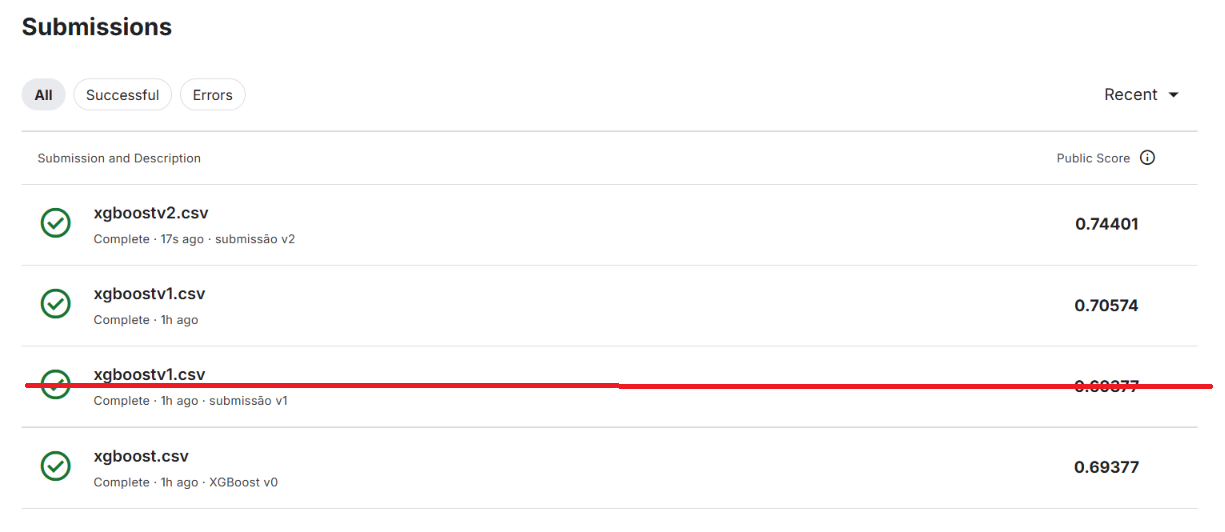

In [48]:
Image('Modelo v2.png')

Agora sim observamos uma melhora no desempenho do modelo.

A pontuação de **0,74401** foi superior aos resultados alcançados durante as aulas, indicando que os ajustes realizados contribuíram para uma melhor capacidade de generalização e desempenho no conjunto de teste.